In [1]:
import os
import re
import pandas as pd

In [1]:
import os
import re
import pandas as pd

# Directory where your log files are stored
log_dir = "../2-DGL_Training/Training_files/"

# List of log files to include
target_logs = {
    "rotatE_64_emb_final.log": "RotatE_64_Emb",
    "rotatE_128_emb_128Hidim_final.log": "RotatE_128_Emb",
    "rotatE_256_emb_256Hidim_final.log": "RotatE_256_Emb",
    "rotatE_512_emb_512Hidim_final.log": "RotatE_512_Emb",
}

# Dictionary to collect model loss series
loss_data = {}

# Process each target log file
for log_filename, model_name in target_logs.items():
    filepath = os.path.join(log_dir, log_filename)

    step_loss_map = {}

    with open(filepath, 'r') as file:
        for line in file:
            if "average loss" in line:
                match = re.search(r"\((\d+)/\d+\).*?average loss: ([\d.]+)", line)
                if match:
                    step, loss = match.groups()
                    step = int(step)
                    loss = float(loss)

                    # Accumulate all losses for this step
                    if step not in step_loss_map:
                        step_loss_map[step] = []
                    step_loss_map[step].append(loss)

    # Compute average loss per step
    averaged_steps = []
    averaged_losses = []

    for step, losses in step_loss_map.items():
        averaged_steps.append(step)
        averaged_losses.append(sum(losses) / len(losses))

    print(f"🔁 {model_name}: {sum(len(v) > 1 for v in step_loss_map.values())} steps had duplicates and were averaged.")

    # Store in dictionary
    loss_data[model_name + "_Avloss"] = pd.Series(data=averaged_losses, index=averaged_steps)

# Combine all models into one DataFrame (aligned by Step)
loss_df = pd.DataFrame(loss_data)
loss_df.index.name = "Step"
loss_df.reset_index(inplace=True)

# Optional: save to CSV
loss_df.to_csv("RotatE_Increasing_embedding_stepwise_losses.csv", index=False)

loss_df


🔁 RotatE_64_Emb: 0 steps had duplicates and were averaged.
🔁 RotatE_128_Emb: 407 steps had duplicates and were averaged.
🔁 RotatE_256_Emb: 406 steps had duplicates and were averaged.
🔁 RotatE_512_Emb: 409 steps had duplicates and were averaged.


,Step,RotatE_64_Emb_Avloss,RotatE_128_Emb_Avloss,RotatE_256_Emb_Avloss,RotatE_512_Emb_Avloss
0,10000,0.648749,0.691712,0.905451,1.327561
1,20000,0.640729,0.682800,0.831773,1.142246
2,30000,0.637635,0.633459,0.703013,0.896329
3,40000,0.629770,0.599747,0.624137,0.752618
4,50000,0.620710,0.577891,0.574107,0.663404
...,...,...,...,...,...
404,4050000,0.402738,0.282351,0.255957,0.250004
405,4060000,0.402469,0.282395,0.255917,0.250037
406,4070000,0.402012,0.282240,0.255904,0.250121
407,4080000,0.402104,0.282219,0.255878,0.250123


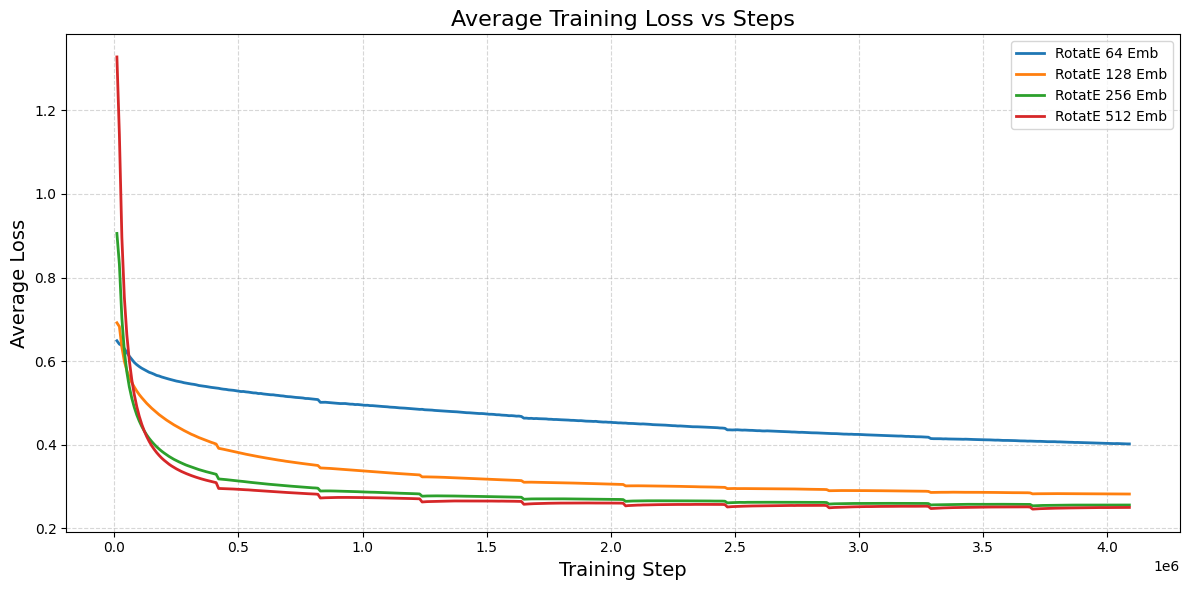

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data (if not already loaded)
# loss_df = pd.read_csv("filtered_stepwise_losses.csv")  # if saved to CSV

# Line plot
plt.figure(figsize=(12, 6))

plt.plot(loss_df["Step"], loss_df["RotatE_64_Emb_Avloss"], label="RotatE 64 Emb", linewidth=2)
plt.plot(loss_df["Step"], loss_df["RotatE_128_Emb_Avloss"], label="RotatE 128 Emb", linewidth=2)
plt.plot(loss_df["Step"], loss_df["RotatE_256_Emb_Avloss"], label="RotatE 256 Emb", linewidth=2)
plt.plot(loss_df["Step"], loss_df["RotatE_512_Emb_Avloss"], label="RotatE 512 Emb", linewidth=2)



plt.title("Average Training Loss vs Steps", fontsize=16)
plt.xlabel("Training Step", fontsize=14)
plt.ylabel("Average Loss", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

